<a href="https://colab.research.google.com/github/sejal-176/Code4Cure_ArchiTech.md/blob/main/PacketSense.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving network_data.csv.csv to network_data.csv.csv


In [ ]:
!pip install pandas scikit-learn

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest

# Load data
data = pd.read_csv("network_data.csv.csv")

# Keep required columns
data = data[['Time', 'Source', 'Destination', 'Protocol', 'Length']]
data = data.dropna()

# Encode categorical data
le = LabelEncoder()
data['Source'] = le.fit_transform(data['Source'])
data['Destination'] = le.fit_transform(data['Destination'])
data['Protocol'] = le.fit_transform(data['Protocol'])

# Features
features = data[['Source', 'Destination', 'Protocol', 'Length']]

# Train model
model = IsolationForest(contamination=0.05)
model.fit(features)

# Predict anomalies
data['Anomaly'] = model.predict(features)

# Show results
print("Total anomalies:", (data['Anomaly'] == -1).sum())
data.head()

Total anomalies: 859


,Time,Source,Destination,Protocol,Length,Anomaly
0,0.000000,42,62,7,147,1
1,0.010391,61,43,6,74,1
2,0.096236,42,62,6,74,1
3,0.096303,61,43,6,74,1
4,2.228968,80,62,7,98,1


In [ ]:
anomalies = data[data['Anomaly'] == -1]
anomalies.head(10)

,Time,Source,Destination,Protocol,Length,Anomaly
21,15.794877,0,18,4,103,-1
22,15.796387,118,122,4,123,-1
37,18.503272,61,120,3,86,-1
49,23.215986,1,0,1,91,-1
50,23.216145,1,0,1,91,-1
51,23.337961,0,1,1,227,-1
52,23.337961,0,1,1,239,-1
66,23.742957,14,62,9,86,-1
71,23.907982,14,62,9,86,-1
192,26.394480,14,62,9,85,-1


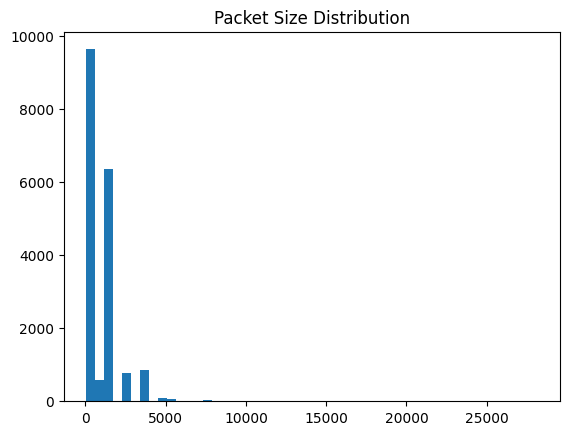

In [ ]:
import matplotlib.pyplot as plt

plt.hist(data['Length'], bins=50)
plt.title("Packet Size Distribution")
plt.show()

In [ ]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)
files.download("model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>